Config

In [ ]:
!unzip /content/drive/MyDrive/Graduate_Project/non_uniform.zip

Archive:  /content/drive/MyDrive/Graduate_Project/non_uniform.zip
   creating: non_uniform/
  inflating: non_uniform/non_uniform0017 (1).jpg  
  inflating: non_uniform/Non_uniform0017.jpg  
  inflating: non_uniform/non_uniform0025 (1).jpg  
  inflating: non_uniform/non_uniform0026 (1).jpg  
  inflating: non_uniform/non_uniform0027 (1).jpg  
  inflating: non_uniform/non_uniform0029 (1).jpg  
  inflating: non_uniform/Non_uniform0029.jpg  
  inflating: non_uniform/non_uniform0031 (1).jpg  
  inflating: non_uniform/non_uniform0032 (1).jpg  
  inflating: non_uniform/Non_uniform0035.jpg  
  inflating: non_uniform/non_uniform0036 (1).jpg  
  inflating: non_uniform/non_uniform0039 (1).jpg  
  inflating: non_uniform/non_uniform0041 (1).jpg  
  inflating: non_uniform/non_uniform0043 (1).jpg  
  inflating: non_uniform/non_uniform0044 (1).jpg  
  inflating: non_uniform/Non_uniform0044.jpg  
  inflating: non_uniform/non_uniform0047 (1).jpg  
  inflating: non_uniform/non_uniform0048 (1).jpg  
  infl

In [ ]:
from pathlib import Path

# =========================
# PATH
# =========================

DATASET_DIR = Path("/content/non_uniform")

OUTPUT_DIR = Path("d/content/Dataset_upperbody")

# =========================
# DATASET
# =========================

SPLITS = ["train", "val", "test"]

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

# =========================
# YOLO
# =========================

YOLO_MODEL_PATH = "yolo26n.pt"

PERSON_CLASS_ID = 0
CONF_THRESHOLD = 0.3

Load YOLO

In [ ]:
from ultralytics import YOLO
model = YOLO(YOLO_MODEL_PATH)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


Detect people

In [ ]:
def get_all_person_bboxes(image):

    results = model.predict(
        source=image,
        classes=[PERSON_CLASS_ID],
        conf=CONF_THRESHOLD,
        verbose=False
    )

    result = results[0]

    if result.boxes is None or len(result.boxes) == 0:
        return []

    boxes = result.boxes.xyxy.cpu().numpy()
    confidences = result.boxes.conf.cpu().numpy()

    detections = []

    for bbox, confidence in zip(boxes, confidences):

        x1, y1, x2, y2 = bbox.astype(int)

        detections.append({
            "bbox": [x1, y1, x2, y2],
            "confidence": float(confidence)
        })

    return detections

Adaptive crop

In [ ]:
def get_crop_ratio(person_height_ratio):

    if person_height_ratio < 0.55:
        # Full body / người đứng xa
        return 0.6

    elif person_height_ratio < 0.85:
        # Medium shot
        return 0.7

    else:
        # Close-up
        return 1.0

Crop upper-body

In [ ]:
def crop_upper_body(image, bbox):

    image_h, image_w = image.shape[:2]

    x1, y1, x2, y2 = map(int, bbox)

    # Clamp bbox vào image boundary
    x1 = max(0, x1)
    y1 = max(0, y1)

    x2 = min(image_w, x2)
    y2 = min(image_h, y2)

    person_h = y2 - y1

    if person_h <= 0:
        return None, None

    person_height_ratio = person_h / image_h

    crop_ratio = get_crop_ratio(person_height_ratio)

    upper_y2 = int(y1 + person_h * crop_ratio)
    upper_y2 = min(upper_y2, image_h)

    upper_body = image[y1:upper_y2, x1:x2]

    crop_info = {
        "original_bbox": [x1, y1, x2, y2],
        "person_height_ratio": person_height_ratio,
        "crop_ratio": crop_ratio,
        "upper_body_bbox": [x1, y1, x2, upper_y2]
    }

    return upper_body, crop_info

Test random images

In [ ]:
import random


def get_random_images(
    dataset_dir,
    num_samples=20
):

    images = []
    for file in dataset_dir.iterdir():

        if file.suffix.lower() in IMAGE_EXTENSIONS:

            images.append(file)

    return random.sample(
        images,
        min(num_samples, len(images))
    )


sample_paths = get_random_images(
    DATASET_DIR,
    num_samples=20
)

Visualize

In [ ]:
import cv2
import matplotlib.pyplot as plt


def visualize_all_persons(image_path):

    image = cv2.imread(str(image_path))

    if image is None:
        print(f"Cannot read: {image_path}")
        return

    detections = get_all_person_bboxes(image)

    if not detections:
        print(f"No person detected: {image_path.name}")
        return

    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    image_bbox = image_rgb.copy()

    crops = []

    for idx, detection in enumerate(detections, start=1):

        bbox = detection["bbox"]

        x1, y1, x2, y2 = bbox

        # Vẽ bbox person
        cv2.rectangle(
            image_bbox,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            3
        )

        cv2.putText(
            image_bbox,
            f"P{idx}",
            (x1, max(y1 - 10, 0)),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 255, 0),
            2
        )

        upper_body, crop_info = crop_upper_body(
            image,
            bbox
        )

        if upper_body is not None:

            crops.append({
                "person_id": idx,
                "image": upper_body,
                "info": crop_info
            })

    # Tổng số plot = ảnh gốc + tất cả crop
    total_plots = 1 + len(crops)

    fig, axes = plt.subplots(
        1,
        total_plots,
        figsize=(6 * total_plots, 6)
    )

    # Nếu chỉ có 1 plot
    if total_plots == 1:
        axes = [axes]

    # Original + bbox
    axes[0].imshow(image_bbox)
    axes[0].set_title("Original + All Persons")
    axes[0].axis("off")

    # Các crop
    for ax, crop_data in zip(axes[1:], crops):

        crop_rgb = cv2.cvtColor(
            crop_data["image"],
            cv2.COLOR_BGR2RGB
        )

        info = crop_data["info"]

        ax.imshow(crop_rgb)

        ax.set_title(
            f"Person {crop_data['person_id']}\n"
            f"crop={info['crop_ratio']:.2f}"
        )

        ax.axis("off")

    plt.tight_layout()
    plt.show()

Start test

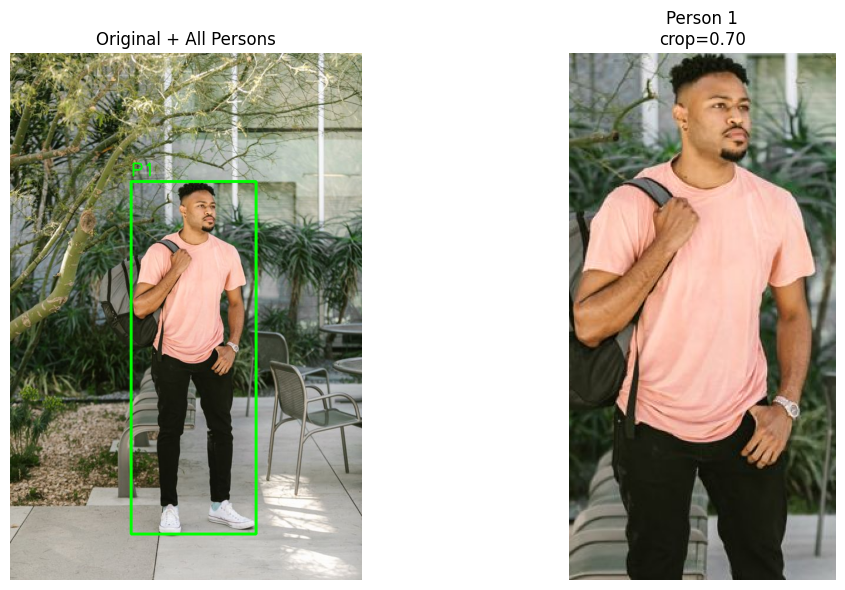

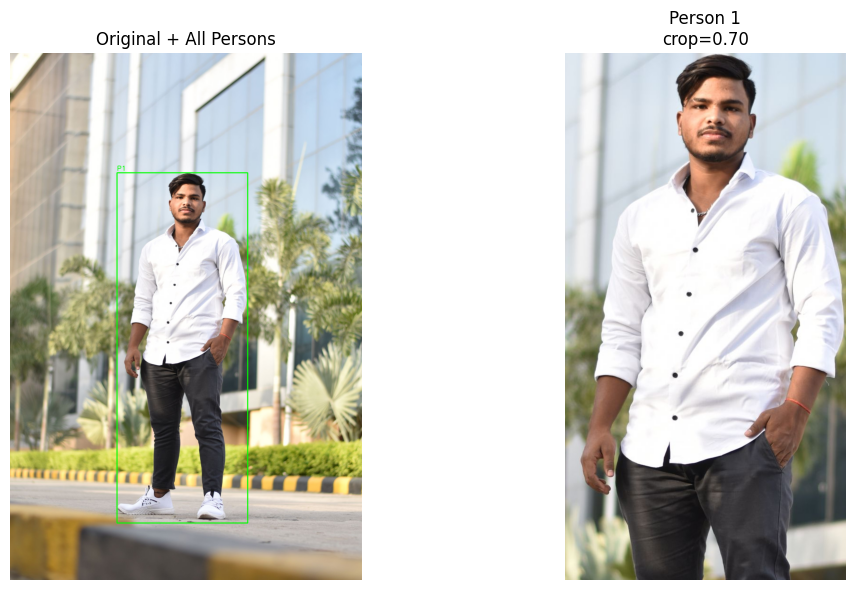

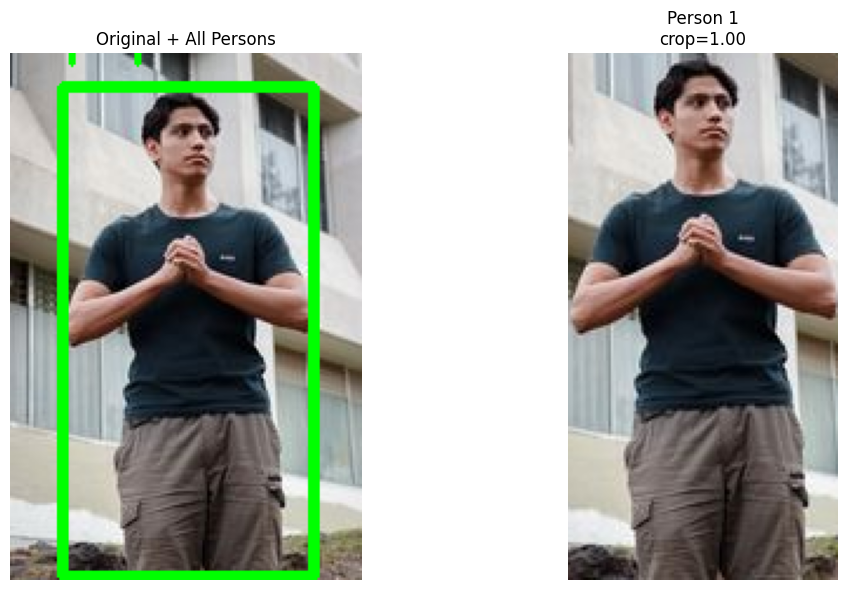

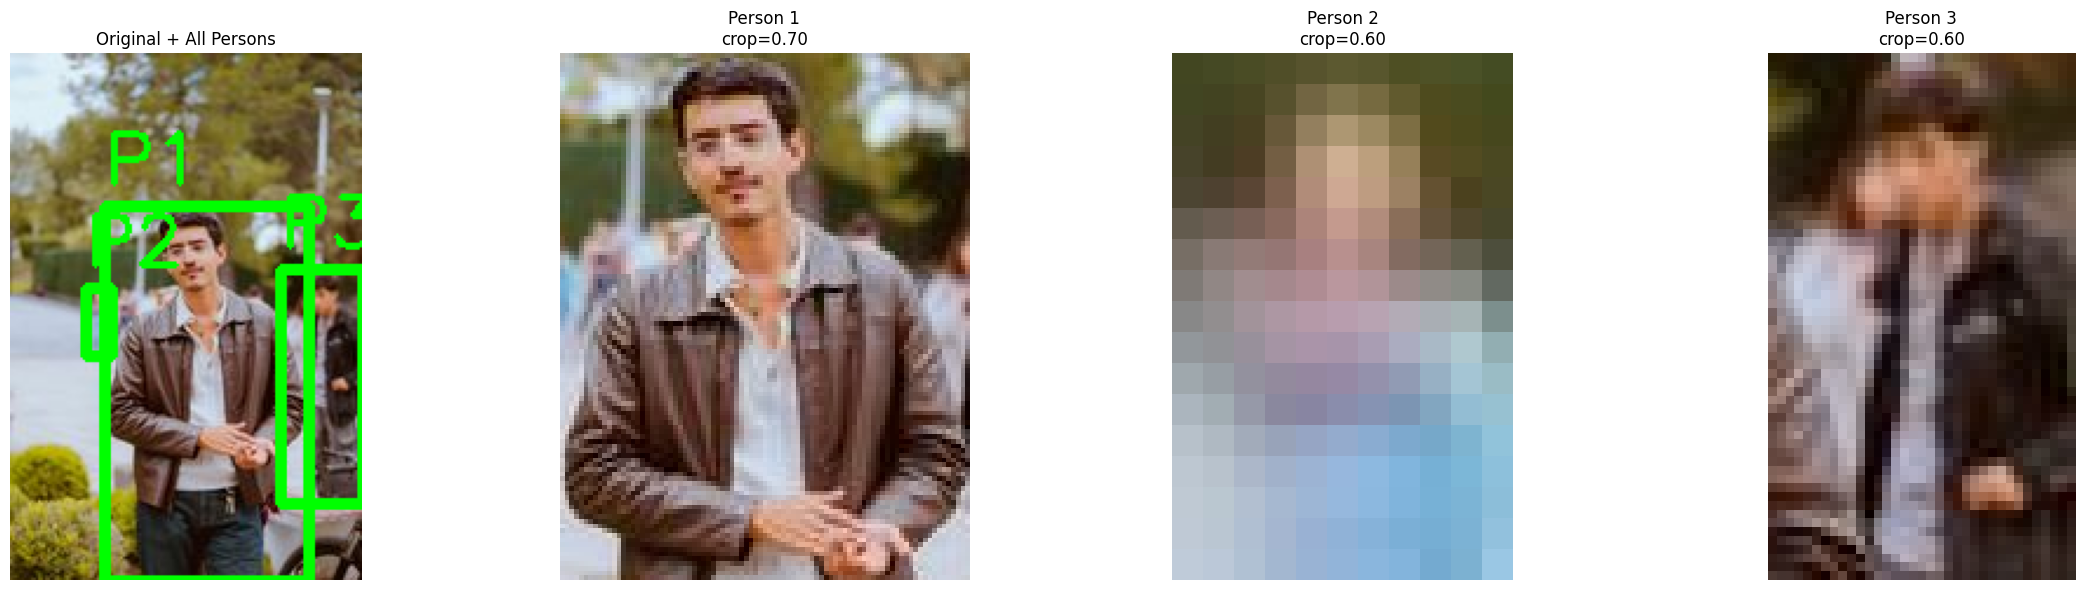

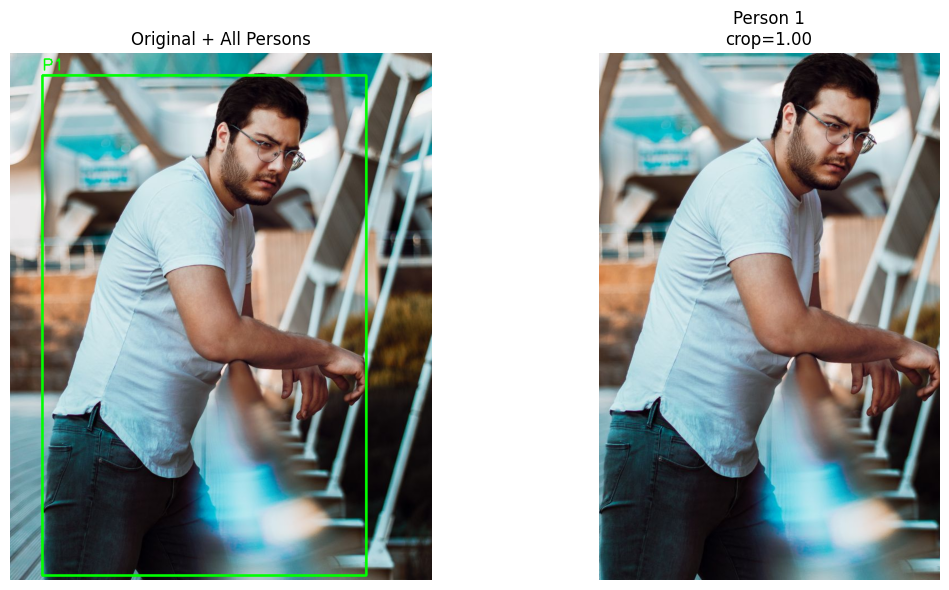

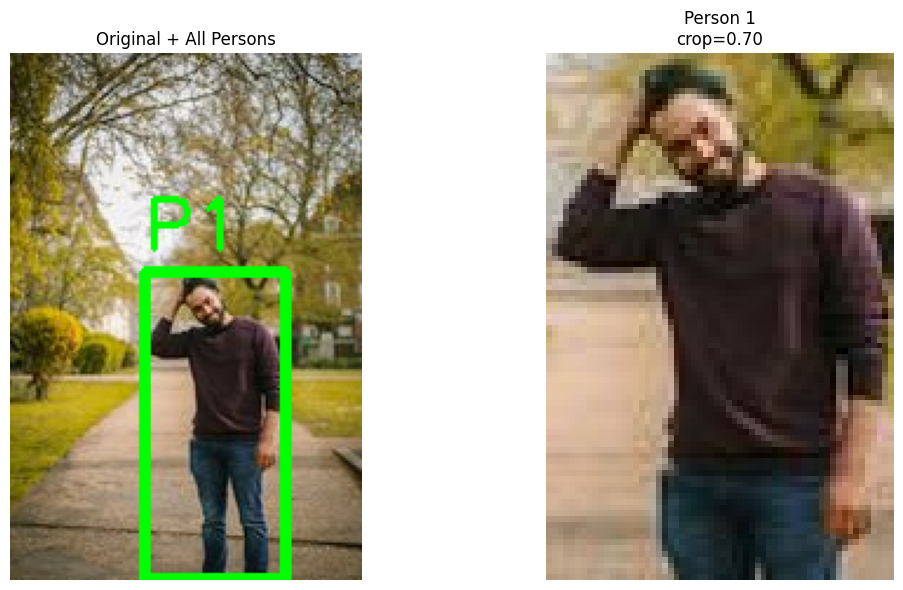

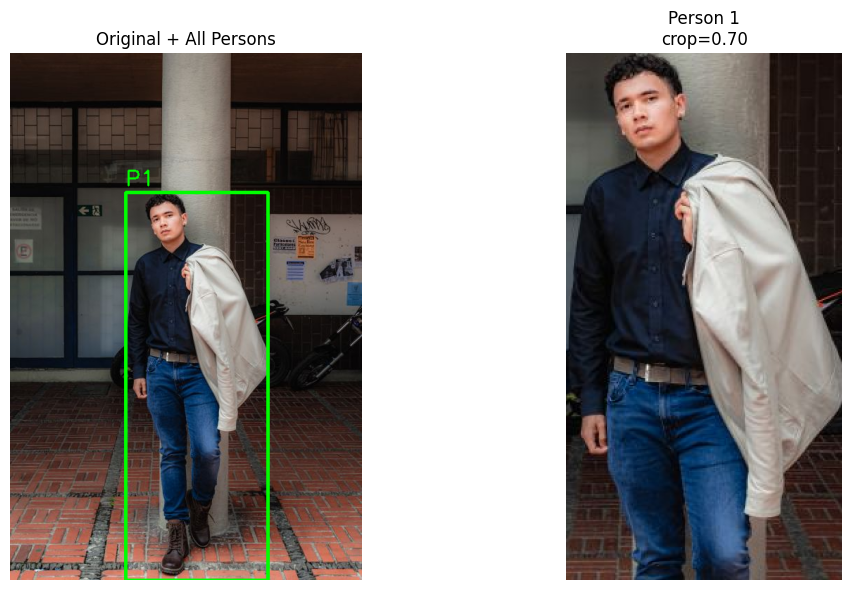

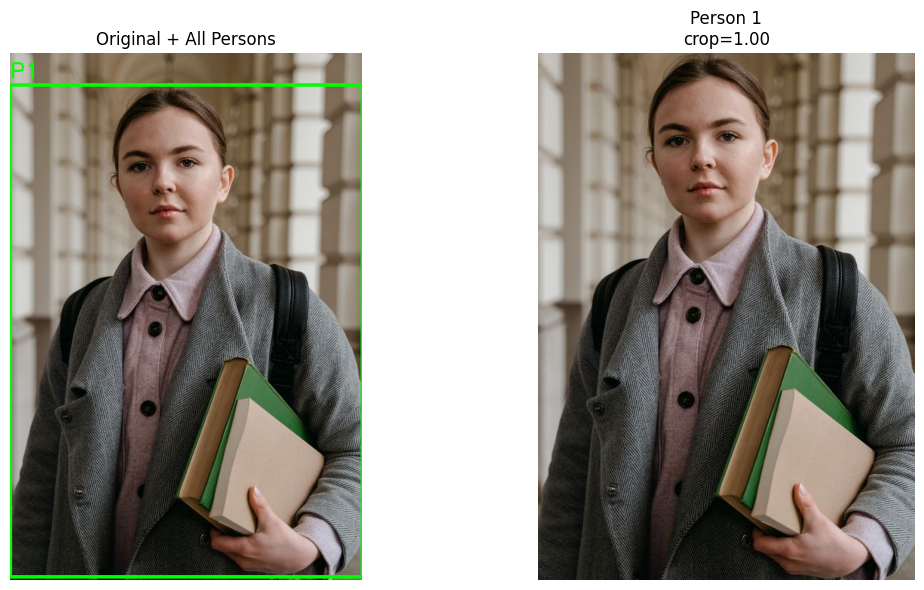

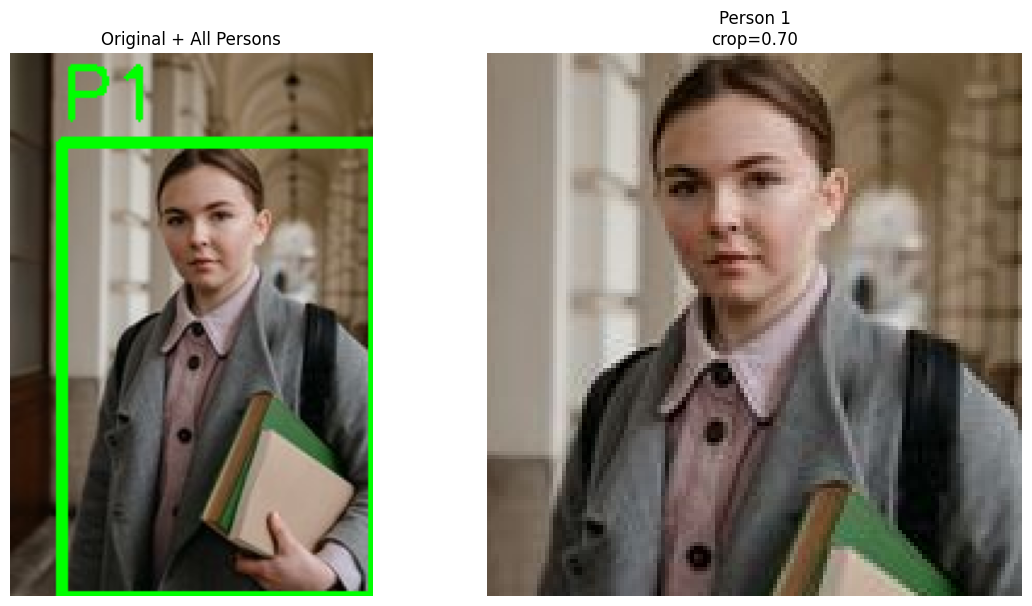

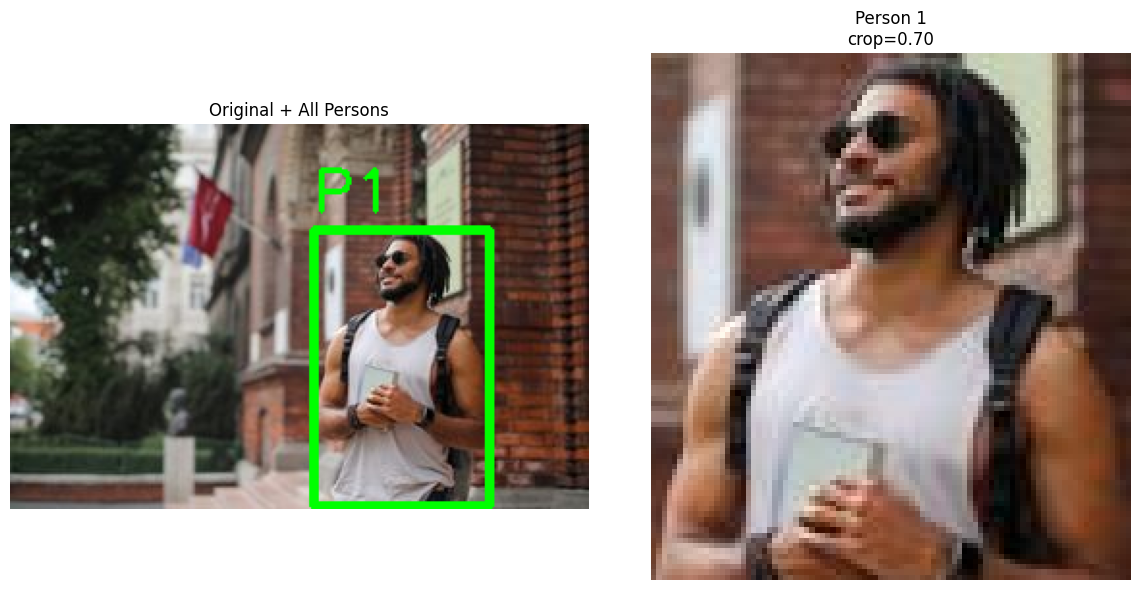

In [ ]:
for path in sample_paths[:10]:
    visualize_all_persons(path)

Create output folder

In [ ]:
from pathlib import Path

OUTPUT_DIR = Path("dataset_upperbody_raw")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

METADATA_PATH = OUTPUT_DIR / "metadata.csv"

Get all images

In [ ]:
def get_all_images(dataset_dir):

    image_paths = []

    for file_path in dataset_dir.iterdir():

        if (
            file_path.is_file()
            and file_path.suffix.lower() in IMAGE_EXTENSIONS
        ):
            image_paths.append(file_path)

    return sorted(image_paths)


image_paths = get_all_images(DATASET_DIR)

print(f"Total images: {len(image_paths)}")

Total images: 517


Batch process

In [ ]:
import cv2
import pandas as pd
from tqdm.auto import tqdm


metadata = []


for image_path in tqdm(
    image_paths,
    desc="Processing images"
):

    image = cv2.imread(str(image_path))

    if image is None:

        metadata.append({
            "source_file": image_path.name,
            "person_id": None,
            "status": "failed_read"
        })

        continue

    # Detect tất cả người
    detections = get_all_person_bboxes(image)

    if not detections:

        metadata.append({
            "source_file": image_path.name,
            "person_id": None,
            "status": "no_person"
        })

        continue

    # Xử lý từng người
    for person_id, detection in enumerate(
        detections,
        start=1
    ):

        bbox = detection["bbox"]
        confidence = detection["confidence"]

        upper_body, crop_info = crop_upper_body(
            image,
            bbox
        )

        if upper_body is None:

            metadata.append({
                "source_file": image_path.name,
                "person_id": person_id,
                "status": "crop_failed"
            })

            continue

        # Tạo filename
        output_name = (
            f"{image_path.stem}"
            f"_p{person_id:02d}"
            f".jpg"
        )

        output_path = OUTPUT_DIR / output_name

        # Save crop
        success = cv2.imwrite(
            str(output_path),
            upper_body
        )

        if success:

            metadata.append({
                "source_file": image_path.name,
                "output_file": output_name,
                "person_id": person_id,
                "confidence": confidence,

                "original_x1": crop_info["original_bbox"][0],
                "original_y1": crop_info["original_bbox"][1],
                "original_x2": crop_info["original_bbox"][2],
                "original_y2": crop_info["original_bbox"][3],

                "person_height_ratio":
                    crop_info["person_height_ratio"],

                "crop_ratio":
                    crop_info["crop_ratio"],

                "status": "success"
            })

        else:

            metadata.append({
                "source_file": image_path.name,
                "person_id": person_id,
                "status": "save_failed"
            })

Processing images:   0%|          | 0/517 [00:00<?, ?it/s]

Save metadata

In [ ]:
metadata_df = pd.DataFrame(metadata)

metadata_df.to_csv(
    METADATA_PATH,
    index=False
)

metadata_df.head()

,source_file,output_file,person_id,confidence,original_x1,original_y1,original_x2,original_y2,person_height_ratio,crop_ratio,status
0,Non_uniform0017.jpg,Non_uniform0017_p01.jpg,1,0.764983,12,60,128,225,0.733333,0.7,success
1,Non_uniform0029.jpg,Non_uniform0029_p01.jpg,1,0.928311,280,227,558,1194,0.805833,0.7,success
2,Non_uniform0035.jpg,Non_uniform0035_p01.jpg,1,0.951647,75,234,489,900,0.740000,0.7,success
3,Non_uniform0035.jpg,Non_uniform0035_p02.jpg,2,0.817236,474,359,598,702,0.381111,0.6,success
4,Non_uniform0035.jpg,Non_uniform0035_p03.jpg,3,0.382462,49,376,85,462,0.095556,0.6,success


In [ ]:
!zip -r dataset_upperbody_raw.zip /content/dataset_upperbody_raw

  adding: content/dataset_upperbody_raw/ (stored 0%)
  adding: content/dataset_upperbody_raw/Non_uniform0747_p01.jpg (deflated 0%)
  adding: content/dataset_upperbody_raw/non_uniform0094 (1)_p01.jpg (deflated 0%)
  adding: content/dataset_upperbody_raw/non_uniform0140 (1)_p01.jpg (deflated 1%)
  adding: content/dataset_upperbody_raw/non_uniform0671 (1)_p01.jpg (deflated 0%)
  adding: content/dataset_upperbody_raw/non_uniform0121 (1)_p01.jpg (deflated 6%)
  adding: content/dataset_upperbody_raw/non_uniform0225 (1)_p02.jpg (deflated 3%)
  adding: content/dataset_upperbody_raw/Non_uniform3505_p02.jpg (deflated 4%)
  adding: content/dataset_upperbody_raw/Non_uniform0672_p01.jpg (deflated 0%)
  adding: content/dataset_upperbody_raw/Non_uniform0272_p01.jpg (deflated 3%)
  adding: content/dataset_upperbody_raw/non_uniform0280 (1)_p01.jpg (deflated 0%)
  adding: content/dataset_upperbody_raw/non_uniform0225 (1)_p04.jpg (deflated 17%)
  adding: content/dataset_upperbody_raw/Non_uniform0162_p02.

In [ ]:
print(metadata_df["status"].value_counts())

status
success    680
Name: count, dtype: int64


In [ ]:
total_source_images = len(image_paths)

total_crops = (
    metadata_df["status"] == "success"
).sum()

print(f"Source images: {total_source_images}")
print(f"Generated crops: {total_crops}")

Source images: 517
Generated crops: 680


In [ ]:
import os

total_size = sum(
    f.stat().st_size
    for f in OUTPUT_DIR.rglob("*")
    if f.is_file()
)

print(f"Dataset size: {total_size / 1024 / 1024:.2f} MB")

Dataset size: 1527.01 MB
